No warm start provided; computing warm start using PD control.
No warm start provided; computing warm start using PD control.
No warm start provided; computing warm start using PD control.
No warm start provided; computing warm start using PD control.
4000 4000


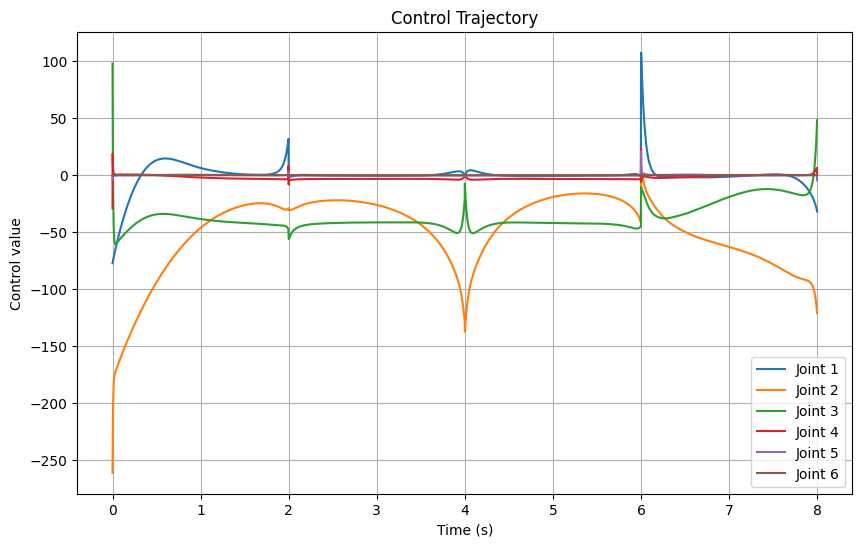

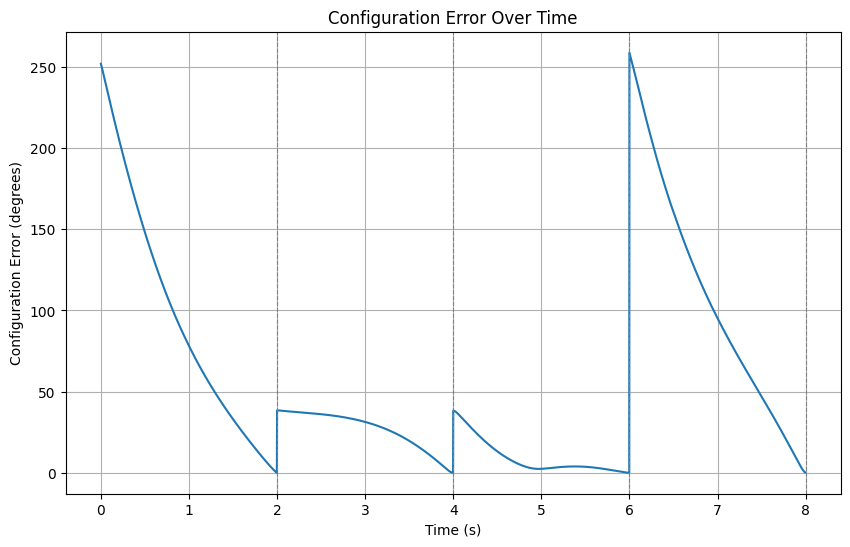

In [9]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10, UR10_sandbox
from optimal.metrics import thermal_energy, mechanical_work, peak_power
import numpy as np
import crocoddyl

type = UR10_sandbox
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

DT = robot_mj_model.model.opt.timestep
path = [robot_pin_model.current_q(),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([0.4, -0.4, 1.5, -0.8, 1.5, 0.5])]
controller = RobotController(robot_pin_model)
xs, us = [], []
v_start = np.zeros(len(robot_pin_model.v_indices))
for i in range(len(path) - 1):
    start = np.concatenate([path[i], v_start])
    target = np.concatenate([path[i+1], np.zeros(len(robot_pin_model.v_indices))])
    t_xs, t_us = controller.compute_control(x_start=start, 
                                        x_goal=target, 
                                        T=1000, DT=DT, kp=type.kp, kd=type.kd,
                                        option="crocoddyl", solver=crocoddyl.SolverBoxFDDP)
    xs.extend(t_xs)
    us.extend(t_us)
    v_start = xs[-1][len(robot_pin_model.q_indices):]

print(len(xs), len(us))
# xs_real, us_real = robot_mj_model.visualize("position", xs=xs, dt=DT, hold=False)
# xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.closed_loop_kp, kd=type.closed_loop_kd, dt=DT, hold=False, plot=True)
# xs_real, us_real = robot_mj_model.visualize("control", us=us, dt=DT, hold=False)
xs_real, us_real = robot_mj_model.simulate_control(us=us, xs=xs, kp=type.kp, kd=type.kd)
# xs_real, us_real = robot_mj_model.simulate_control(us=us)
# robot_mj_model.plot_controls(us, dt=DT)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)

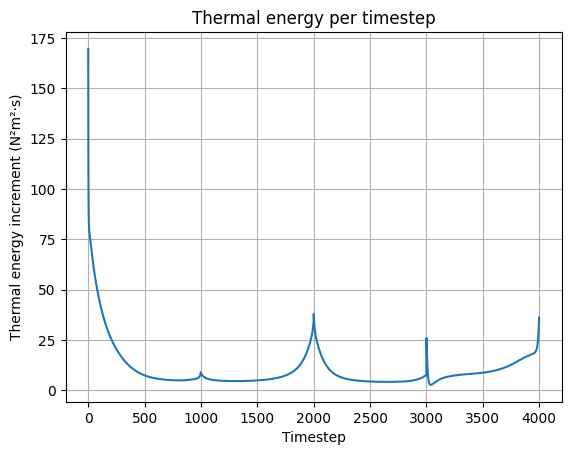

Thermal energy: 41549.70932520459


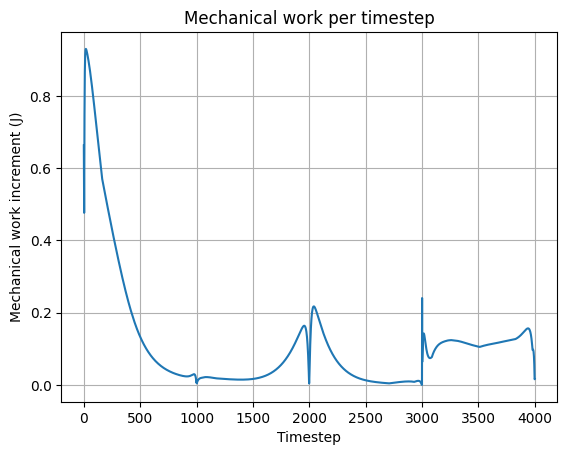

Mechanical work: 468.757491991298


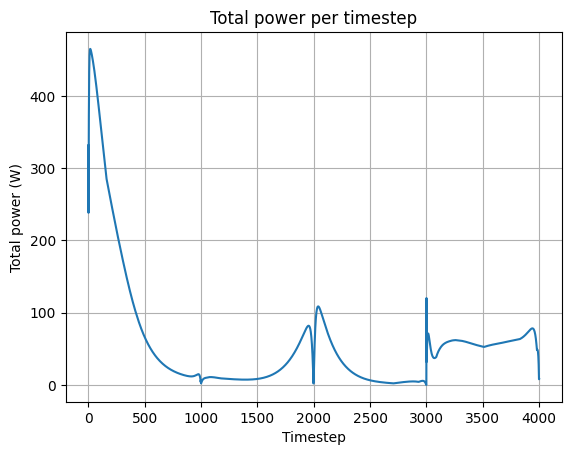

Peak power: 464.9084169033178


In [10]:
from optimal.metrics import thermal_energy, mechanical_work, peak_power

E_th  = thermal_energy(us_real, DT, True)
print("Thermal energy:", E_th)
E_mech = mechanical_work(us_real, xs_real, DT, True)
print("Mechanical work:", E_mech)
P_peak = peak_power(us_real, xs_real, True)
print("Peak power:", P_peak)